In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile as wav
from scipy.signal import windows, spectrogram, stft, istft
from scipy.signal.windows import hann
import typing

In [16]:
sample_rate, raw_data = wav.read("1-5_wn.wav")
sample_count = len(raw_data)

In [17]:
raw_data

array([  0,   0,   0, ..., 249, 563, 946], dtype=int16)

In [703]:
print(f"Sampling rate: {sample_rate}Hz")

Sampling rate: 16000Hz


In [705]:
print(f"Sample count: {sample_count}")

Sample count: 115840


In [707]:
recording_length = sample_count / sample_rate 

In [709]:
print(f"Recording length: {recording_length}s")

Recording length: 7.24s


In [710]:
data_type = raw_data.dtype

In [713]:
print(f"Sample data type: {data_type}")

Sample data type: int16


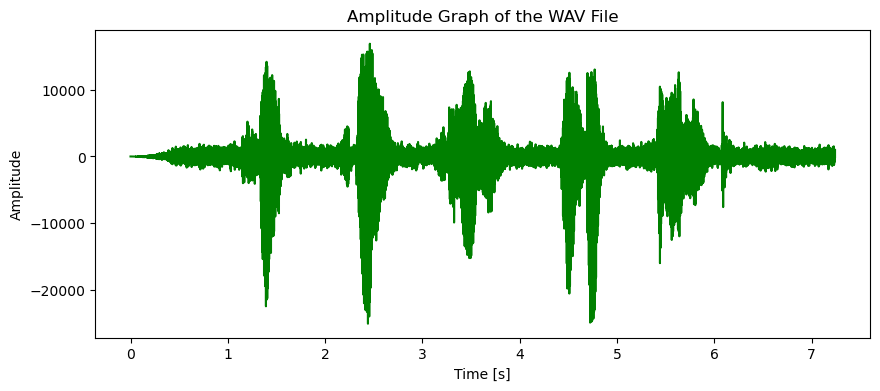

In [714]:
time = np.linspace(0, recording_length, sample_count)

# Plot the waveform
plt.figure(figsize=(10, 4))
plt.plot(time, raw_data, color="green")
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
#plt.xlim([start_time, end_time])
plt.title('Amplitude Graph of the WAV File')
plt.show()

## Analysing white noise

In [717]:
wn_sample_rate, wn_raw_data = wav.read("white_noise.wav")
wn_sample_count = len(wn_raw_data)
wn_recording_length = wn_sample_count / wn_sample_rate

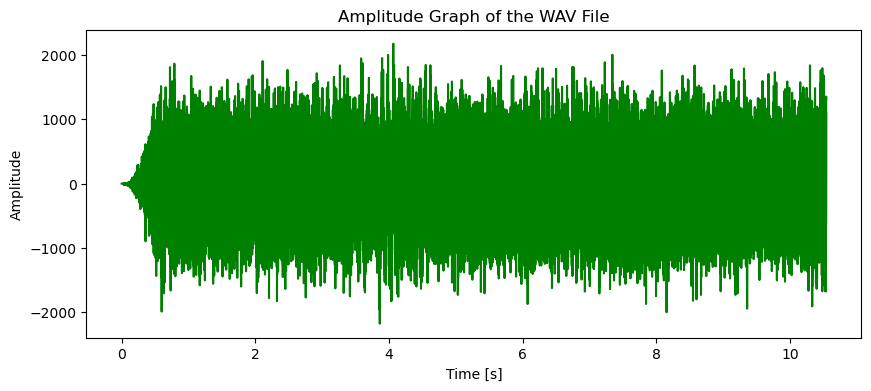

In [719]:
wn_time = np.linspace(0, wn_recording_length, wn_sample_count)

# Plot the waveform
plt.figure(figsize=(10, 4))
plt.plot(wn_time, wn_raw_data, color="green")
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
#plt.xlim([start_time, end_time])
plt.title('Amplitude Graph of the WAV File')
plt.show()

In [721]:
wn_frequencies, wn_time_segments, wn_spectogram = stft(wn_raw_data, fs=wn_sample_rate, nperseg=1024)

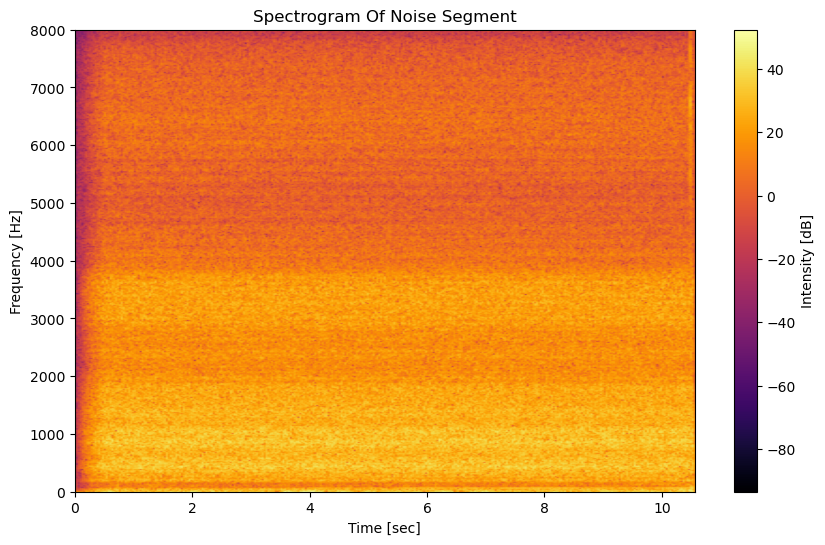

In [723]:
# Plot the spectrogram
plt.figure(figsize=(10, 6))
plt.pcolormesh(wn_time_segments, wn_frequencies, 20 * np.log10(np.abs(wn_spectogram) + 1e-10), shading='gouraud', cmap="inferno")
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Spectrogram Of Noise Segment')
plt.colorbar(label='Intensity [dB]')
plt.show()

In [725]:
frequencies, time_segments, spectogram = stft(raw_data, fs=sample_rate, nperseg=1024)

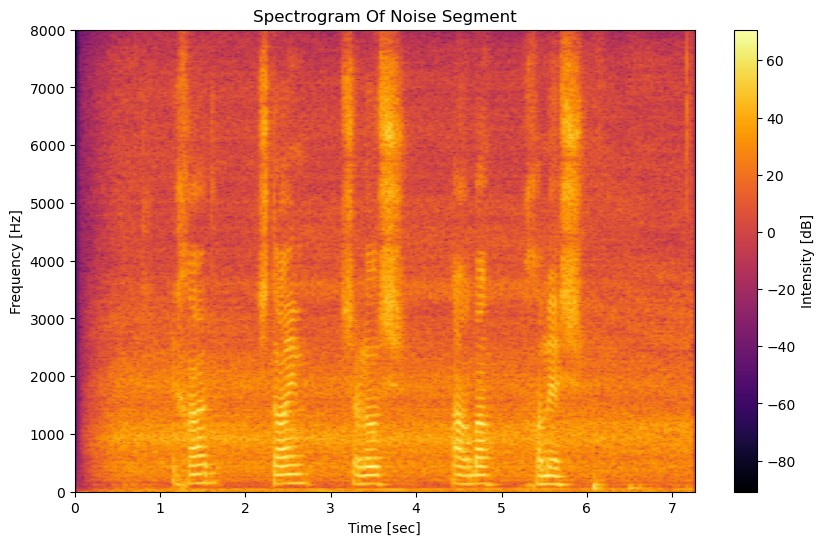

In [726]:
# Plot the spectrogram
plt.figure(figsize=(10, 6))
plt.pcolormesh(time_segments, frequencies, 20 * np.log10(np.abs(spectogram) + 1e-10), shading='gouraud', cmap="inferno")
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Spectrogram Of Speech Segment')
plt.colorbar(label='Intensity [dB]')
plt.show()

In [727]:
nn_sample_rate, nn_raw_data = wav.read("1-5_no_noise.wav")
nn_sample_count = len(nn_raw_data)
nn_recording_length = nn_sample_count / nn_sample_rate

In [729]:
nn_frequencies, nn_time_segments, nn_spectogram = stft(nn_raw_data, fs=nn_sample_rate, nperseg=1024)

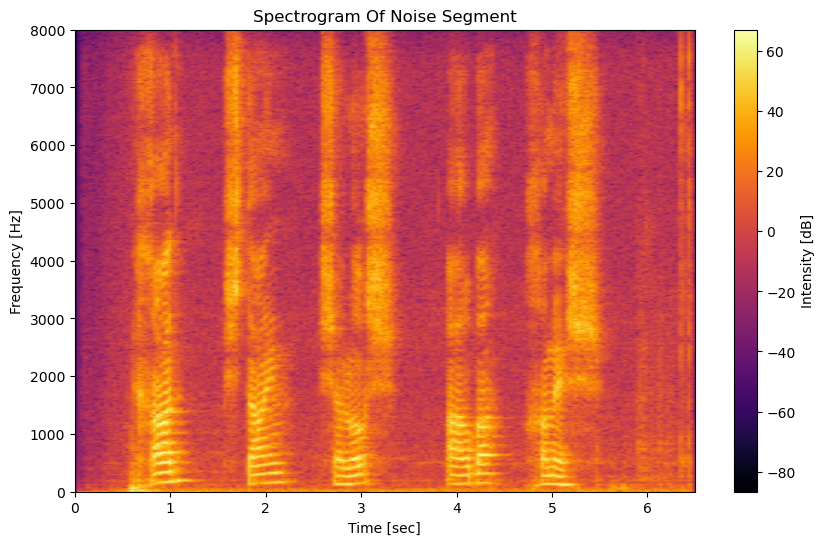

In [734]:
# Plot the spectrogram
plt.figure(figsize=(10, 6))
plt.pcolormesh(nn_time_segments, nn_frequencies, 20 * np.log10(np.abs(nn_spectogram) + 1e-10), shading='gouraud', cmap="inferno")
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Spectrogram Of Noise-Free Speech Segment')
plt.colorbar(label='Intensity [dB]')
plt.show()

In [750]:
spectogram_clean = spectogram - wn_spectogram[:,:228]

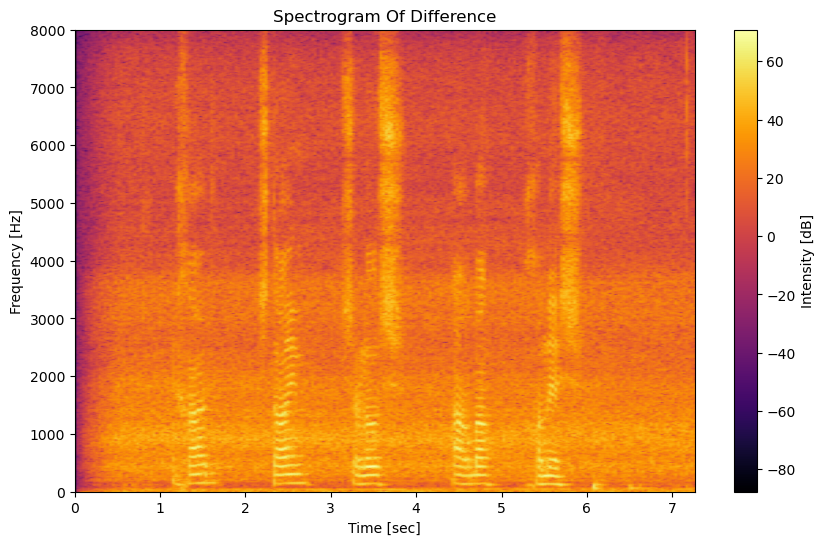

In [772]:
# Plot the spectrogram
plt.figure(figsize=(10, 6))
plt.pcolormesh(time_segments, frequencies, 20 * np.log10(np.abs(spectogram_clean) + 1e-10), shading='gouraud', cmap="inferno")
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Spectrogram Of Difference')
plt.colorbar(label='Intensity [dB]')
plt.show()

## Attempts in noise reduction

#### Magnitude subtraction on entire frequencies of signal

In [649]:
fft_signal = np.fft.fft(raw_data)

In [653]:
assert(len(fft_signal) == sample_count)

In [655]:
frequencies = np.fft.fftfreq(sample_count, d=1/sample_rate)
magnitudes = np.abs(fft_signal)
phases = np.angle(fft_signal)

In [657]:
assert(len(frequencies) == len(magnitudes) == len(fft_signal))

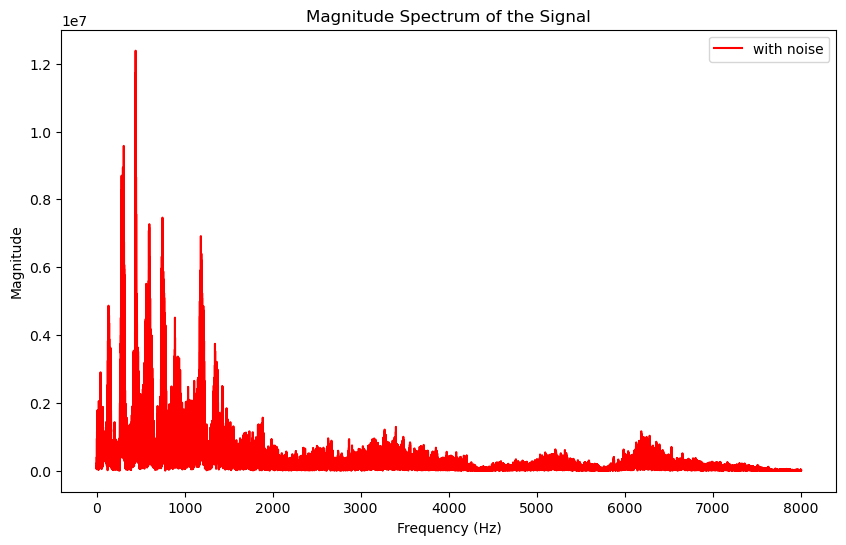

In [659]:
# Plot the magnitude spectrum
plt.figure(figsize=(10, 6))
plt.plot(frequencies[:sample_count // 2], magnitudes[:sample_count // 2], color="red", label="with noise")
plt.legend()
plt.title("Magnitude Spectrum of the Signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

In [660]:
frequencies_abs = np.abs(frequencies)
frequency_cond = (frequencies_abs <= 250) | (frequencies_abs >= 1000)    
frequency_indices = np.where(frequency_cond)

In [661]:
frequency_indices

(array([     0,      1,      2, ..., 115837, 115838, 115839], dtype=int64),)

In [665]:
fft_modified = fft_signal
fft_modified[frequency_indices] = 0 * 0j

In [667]:
# Plot the magnitude spectrum
# plt.figure(figsize=(10, 6))
# plt.plot(frequencies[:sample_count // 2], magnitudes_modified[:sample_count // 2])
# plt.title("Magnitude Spectrum of the Signal")
# plt.xlabel("Frequency (Hz)")
# plt.ylabel("Magnitude")
# plt.show()

In [669]:
modified_signal = np.fft.ifft(fft_modified).real
modified_signal_sample_count = len(modified_signal)
modified_signal_time = modified_signal_sample_count / sample_rate

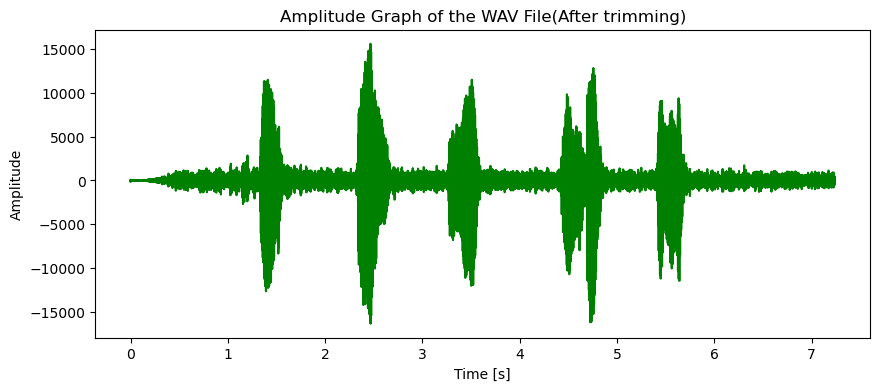

In [671]:
time_modified = np.linspace(0, modified_signal_time, modified_signal_sample_count)

# Plot the waveform
plt.figure(figsize=(10, 4))
plt.plot(time_modified, modified_signal, color="green")
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
#plt.xlim([0, 0.5])
plt.title('Amplitude Graph of the WAV File(After trimming)')
plt.show()

In [673]:
wav.write("1-5_cleaned.wav", sample_rate, modified_signal.astype(np.int16))

#### Simple windowing and STFT using built-in libraries(Magnitude subtraction)

In [649]:
noise_segment = raw_data[:int(sample_rate * 0.5)]
frequencies_noise_segment, times_noise_segment, noise_spectrogram = stft(noise_segment, fs=sample_rate, nperseg=2024, noverlap=None)

In [651]:
noise_spectrogram.shape

(1013, 9)

In [653]:
print(f"Number of frequencies: {noise_spectrogram.shape[0]}\nNumber of frames: {noise_spectrogram.shape[1]}")

Number of frequencies: 1013
Number of frames: 9


In [655]:
noise_spectogram_magnitudes = np.abs(noise_spectrogram)
noise_spectogram_log_magnitudes = 20 * np.log10(noise_spectogram_magnitudes + np.finfo(float).eps) 
noise_magnitude_average = np.mean(noise_spectogram_magnitudes, axis=1)

In [657]:
len(noise_magnitude_average)

1013

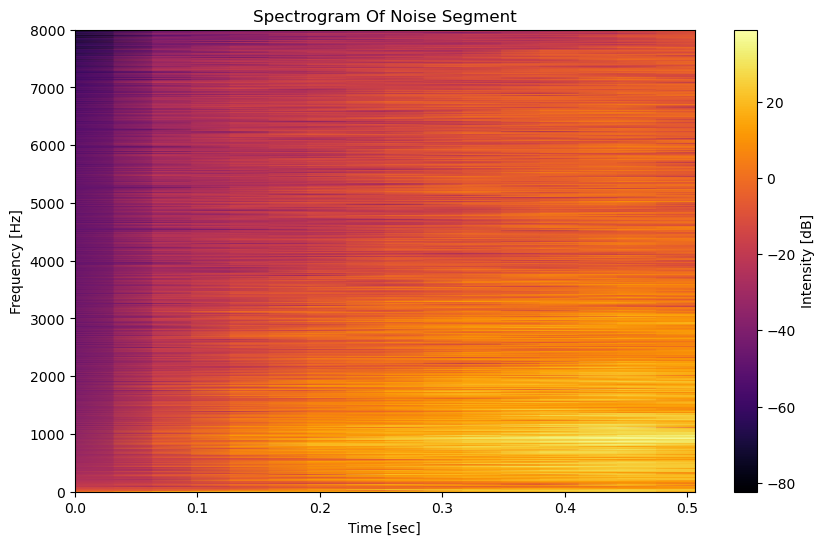

In [659]:
# Plot the spectrogram
plt.figure(figsize=(10, 6))
plt.pcolormesh(times_noise_segment, frequencies_noise_segment, noise_spectogram_log_magnitudes, shading='gouraud', cmap="inferno")
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Spectrogram Of Noise Segment')
plt.colorbar(label='Intensity [dB]')
plt.show()

In [661]:
frequencies_signal, times_signal, noisy_spectrogram_signal = stft(new_data, fs=sample_rate, nperseg=2024, noverlap=None)

In [663]:
clean_spectrogram = np.zeros_like(noisy_spectrogram_signal)

In [665]:
num_of_windows = noisy_spectrogram_signal.shape[1]

In [667]:
print(f"Number of signal windows: {num_of_windows}")

Number of signal windows: 98


In [669]:
log_magnitude_noisy_signal = 20 * np.log10(np.abs(noisy_spectrogram_signal) + np.finfo(float).eps)

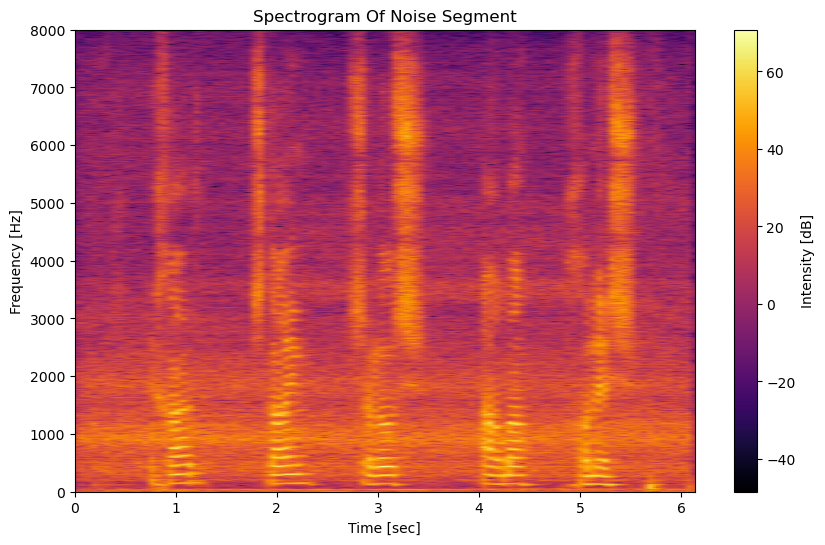

In [671]:
# Plot the spectrogram
plt.figure(figsize=(10, 6))
plt.pcolormesh(times_signal, frequencies_signal, log_magnitude_noisy_signal, shading='gouraud', cmap="inferno")
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Spectrogram Of Noise Segment')
plt.colorbar(label='Intensity [dB]')
plt.show()

In [673]:
#Spectral subtraction of each frame
for i in range(num_of_windows):
    noisy_magnitude = np.abs(noisy_spectrogram_signal[:, i])
    clean_magnitude = np.maximum(noisy_magnitude - noise_magnitude_average, 0)  # Subtract and apply non-negative constraint
    clean_spectrogram[:, i] = clean_magnitude * np.exp(1j * np.angle(noisy_spectrogram_signal[:, i]))  # Combine with original phase

In [675]:
log_magnitude_clean_signal = 20 * np.log10(np.abs(clean_spectrogram) + np.finfo(float).eps)

In [677]:
# Convert the clean spectrogram back to the time domain
_, clean_signal = istft(clean_spectrogram, fs=sample_rate)

# Save the cleaned audio signal
wav.write('cleaned_audio.wav', sample_rate, clean_signal.astype(np.int16))

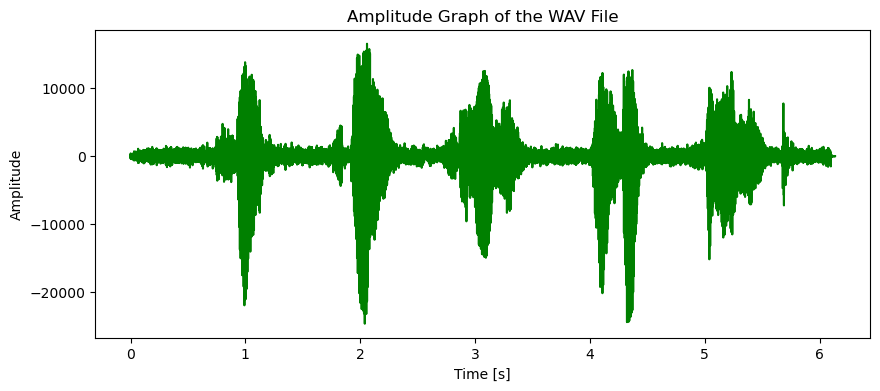

In [679]:
time = np.linspace(0, len(clean_signal) / sample_rate, len(clean_signal))

# Plot the waveform
plt.figure(figsize=(10, 4))
plt.plot(time, clean_signal, color="green")
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
#plt.xlim([start_time, end_time])
plt.title('Amplitude Graph of the WAV File')
plt.show()

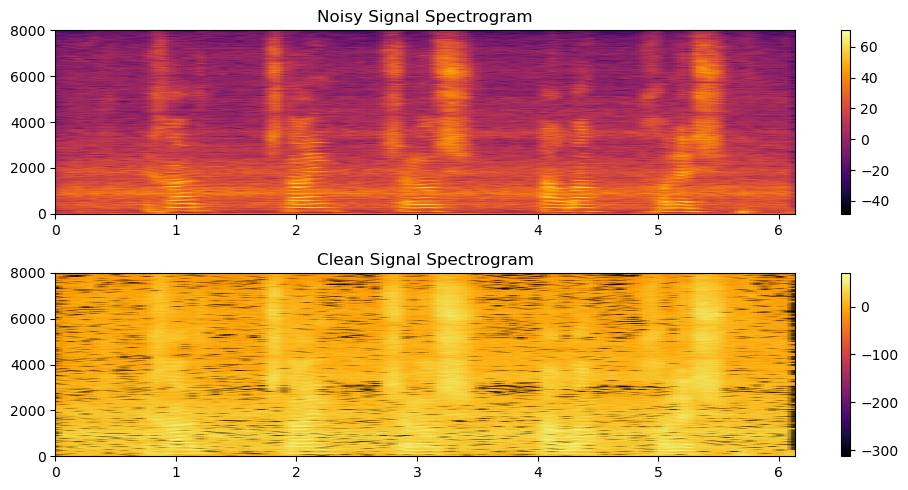

In [681]:
plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.title('Noisy Signal Spectrogram')
plt.pcolormesh(times_signal, frequencies_signal, log_magnitude_noisy_signal, shading='gouraud', cmap="inferno")
plt.colorbar()
plt.subplot(2, 1, 2)
plt.title('Clean Signal Spectrogram')
plt.pcolormesh(times_signal, frequencies_signal, log_magnitude_clean_signal, shading='gouraud', cmap="inferno")
plt.colorbar()
plt.tight_layout()
plt.show()

#### Simple windowing and STFT using built-in libraries(Magnitude subtraction)

In [768]:
window_size = 1024

In [770]:
frequencies_signal, times_signal, dft_noisy_signal = stft(raw_data, fs=sample_rate, nperseg=window_size)

In [772]:
times_signal

array([0.   , 0.032, 0.064, 0.096, 0.128, 0.16 , 0.192, 0.224, 0.256,
       0.288, 0.32 , 0.352, 0.384, 0.416, 0.448, 0.48 , 0.512, 0.544,
       0.576, 0.608, 0.64 , 0.672, 0.704, 0.736, 0.768, 0.8  , 0.832,
       0.864, 0.896, 0.928, 0.96 , 0.992, 1.024, 1.056, 1.088, 1.12 ,
       1.152, 1.184, 1.216, 1.248, 1.28 , 1.312, 1.344, 1.376, 1.408,
       1.44 , 1.472, 1.504, 1.536, 1.568, 1.6  , 1.632, 1.664, 1.696,
       1.728, 1.76 , 1.792, 1.824, 1.856, 1.888, 1.92 , 1.952, 1.984,
       2.016, 2.048, 2.08 , 2.112, 2.144, 2.176, 2.208, 2.24 , 2.272,
       2.304, 2.336, 2.368, 2.4  , 2.432, 2.464, 2.496, 2.528, 2.56 ,
       2.592, 2.624, 2.656, 2.688, 2.72 , 2.752, 2.784, 2.816, 2.848,
       2.88 , 2.912, 2.944, 2.976, 3.008, 3.04 , 3.072, 3.104, 3.136,
       3.168, 3.2  , 3.232, 3.264, 3.296, 3.328, 3.36 , 3.392, 3.424,
       3.456, 3.488, 3.52 , 3.552, 3.584, 3.616, 3.648, 3.68 , 3.712,
       3.744, 3.776, 3.808, 3.84 , 3.872, 3.904, 3.936, 3.968, 4.   ,
       4.032, 4.064,

In [774]:
dft_noisy_signal.shape

(513, 228)

In [776]:
magnitude_noisy_signal = np.abs(dft_noisy_signal)
phase_noisy_signal = np.angle(dft_noisy_signal)
db_magnitude_noisy_signal = 20 * np.log10(magnitude_noisy_signal + 1e-10)

In [778]:
white_noise_db = np.mean(db_magnitude_noisy_signal[:, :10], axis = 1, keepdims=True)
white_noise_magnitude = 10**(white_noise_db / 20)

In [780]:
# Noise suppression: Subtract noise estimate in dB
magnitude_enhanced_db = db_magnitude_noisy_signal - white_noise_db
magnitude_enhanced_db = np.maximum(magnitude_enhanced_db, 0)

In [782]:
magnitude_enhanced = 10**(magnitude_enhanced_db / 20)

In [784]:
dft_enchanced = magnitude_enhanced * np.exp(1j * phase_noisy_signal)

In [786]:
_, y_enhanced = istft(dft_enchanced, fs=sample_rate, nperseg=window_size)

In [788]:
y_enhanced = np.int16(y_enhanced / np.max(np.abs(y_enhanced)) * 32767)

In [790]:
wav.write('cleaned_audio_db.wav', sample_rate, y_enhanced)

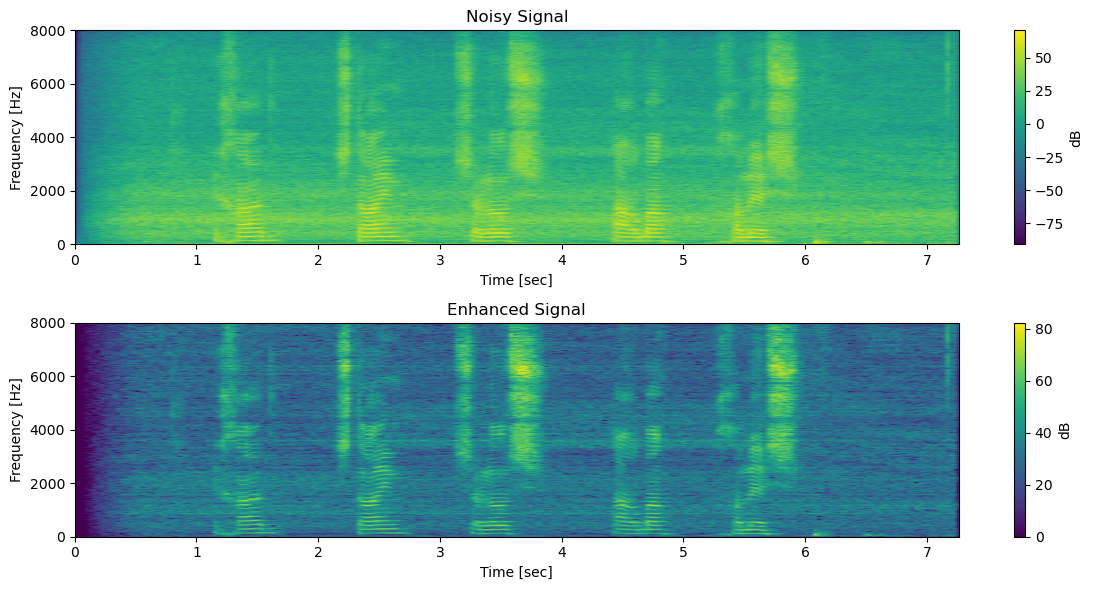

In [792]:
# Plotting the spectrograms
plt.figure(figsize=(12, 6))

# Noisy signal spectrogram
plt.subplot(2, 1, 1)
plt.pcolormesh(times_signal, frequencies_signal, db_magnitude_noisy_signal, shading='gouraud')
plt.title('Noisy Signal')
plt.colorbar(label='dB')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')

# Enhanced signal spectrogram
plt.subplot(2, 1, 2)
plt.pcolormesh(times_signal, frequencies_signal, 20 * np.log10(magnitude_enhanced + 1e-10), shading='gouraud')
plt.title('Enhanced Signal')
plt.colorbar(label='dB')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')

plt.tight_layout()
plt.show()

#### Manual windowing

In [14]:
reconstructed_signal_simple_windowing = np.zeros(new_data_sample_count)

In [15]:
window_size = int(0.8 * sample_rate)
overlap_size = int(0 * sample_rate)
step_size = window_size - overlap_size

In [16]:
windows = np.split(new_data, np.arange(window_size, new_data_sample_count, window_size))

In [17]:
windows_windowed = []

In [18]:
start_index = 0

for window_index in range(len(windows)):
    window_size = len(windows[window_index])
    windows_windowed.append(windows[window_index] * hann(window_size))
    end_index = start_index + window_size

    reconstructed_signal_simple_windowing[start_index:end_index] += windows_windowed[-1]
    start_index = end_index
        

In [19]:
reconstructed_signal_simple_windowing

array([ 0.00000000e+00, -6.02486970e-07,  4.02461271e-05, ...,
       -5.03475582e-04, -1.26794422e-04,  0.00000000e+00])

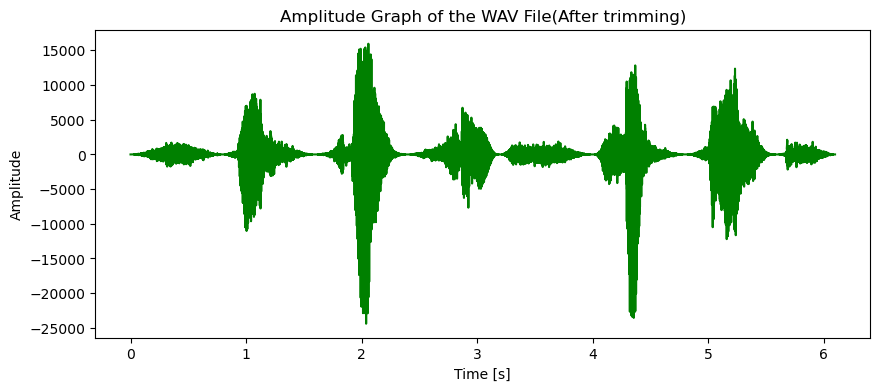

In [20]:
time_new_data = np.linspace(0, new_data_recording_time, new_data_sample_count)

# Plot the waveform
plt.figure(figsize=(10, 4))
plt.plot(time_new_data, reconstructed_signal_simple_windowing, color="green")
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
#plt.xlim([0, 0.5])
plt.title('Amplitude Graph of the WAV File(After trimming)')
plt.show()

In [21]:
wav.write("1-5_attempt_1.wav", sample_rate, reconstructed_signal_simple_windowing.astype(np.int16))

In [22]:
dft = np.fft.fft(new_data)

# Compute the frequency axis for plotting
frequencies = np.fft.fftfreq(new_data_sample_count, d=1/sample_rate)[:new_data_sample_count//2]
magnitude = np.abs(dft[:new_data_sample_count // 2])
magnitude_squared = np.power(magnitude, 2)